## Simulating two vessels passing a lock: multiple vessels in the lock operation
In this notebook, we simulate a lock complex on a network. We model two opposing directed vessels that have to pass the complex. Hence, when one vessel is being levelled, the other vessel has to wait. 

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from shapely.geometry import Point, LineString, Polygon
from shapely.ops import transform

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim

# import of basic core mixins and utils for creating objects, inspecting the output and plotting
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.utils import create_object
from opentnsim.core.visualizations import generate_vessel_gantt_chart

# import of util for graph visualization
from opentnsim.graph.visualizations import plot_graph

# import of modules important for locking
from opentnsim.lock import IsLockChamber, IsLockWaitingArea, IsLockComplex, LockComplexTraversable

# package(s) needed for inspecting the output
import pandas as pd

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 2.2.2.dev105+gc0ed3023c.d20260415


#### 0. Create environment

In [2]:
# start simpy environment
simulation_start = datetime.datetime(2025, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

#### 1. Create graph
In this notebook, we apply a directed-graph with the same laypuot as in Notebook 0201.

In [3]:
# define reference systems
wgs84eqd = pyproj.CRS('4087')
wgs84rad = pyproj.CRS('4326')

# define transformer functions
wgs84eqd_to_wgs84rad = pyproj.transformer.Transformer.from_crs(wgs84eqd,wgs84rad,always_xy=True).transform #equidistant wgs84 to radial wgs84
wgs84rad_to_wgs84eqd = pyproj.transformer.Transformer.from_crs(wgs84rad,wgs84eqd,always_xy=True).transform #radial wgs84 to equidistant wgs84

# create a directed graph
graph = nx.DiGraph()

# add nodes
graph.add_node('0',geometry=transform(wgs84eqd_to_wgs84rad, Point(-5000,0)))
graph.add_node('1',geometry=transform(wgs84eqd_to_wgs84rad, Point(5000,0)))

# add edges
graph.add_edge('0','1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-5000, 0),Point(5000, 0)])), weight=1, length_m=10000)
graph.add_edge('1','0', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(5000, 0),Point(-5000, 0)])), weight=1, length_m=10000)

# add graph to environment
env.graph = graph

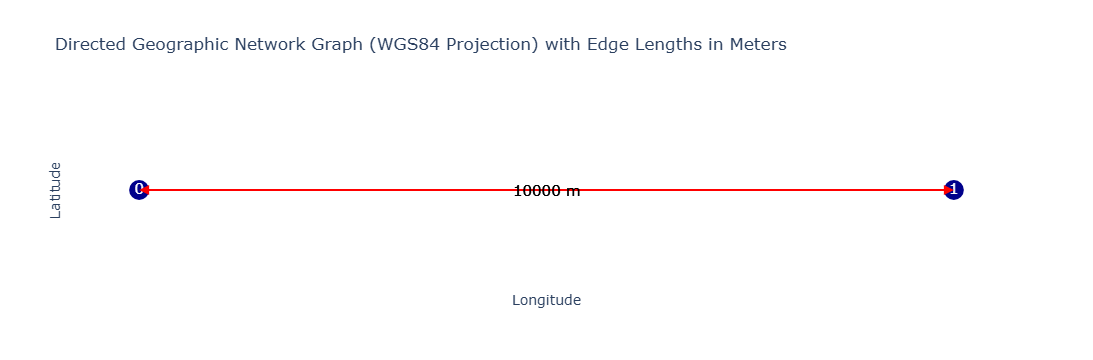

In [4]:
plot_graph(graph)

#### 1+ Adding infrastructure
We create the same objects as in Notebook 0201. For the lock chamber, we now use the geometric approach (b). Using this approach, it can calculate the horizontal lock chamber dimensions automatically.

In [5]:
lock_chamber = IsLockChamber(env=env,
                             lock_depth = 10,
                             name='Lock',
                             gate_open = '0',
                             edge = ('0','1'),
                             geometry_m = Polygon([Point(-200, -25),Point(-200, 25),Point(200, 25),Point(200, -25)]))

In [6]:
waiting_area_A = IsLockWaitingArea(env=env,
                                   name = 'Waiting area A',
                                   edge = ('0','1'),
                                   orientation = 0,
                                   distance_from_edge_start = 0)

waiting_area_B = IsLockWaitingArea(env=env,
                                   name = 'Waiting area B',
                                   edge = ('1','0'),
                                   orientation = 1,
                                   distance_from_edge_start = 0)

In [7]:
lock_complex = IsLockComplex(lock_chambers = [lock_chamber],
                             waiting_areas = [waiting_area_A, waiting_area_B],
                             registration_nodes = ['0','1'],
                             env=env,
                             name = 'Lock complex',)

#### 2. Create agents
We create the same agents, but now with the second vessel having the same direction as the first vessel.

In [8]:
# make your preferred Vessel class out of available mix-ins.
Vessel = create_object(
    "Vessel", 
    (
        LockComplexTraversable,     # allows to interact with a lock (Movable is already included in this mixin)
    ), 
)

In [9]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [10]:
# create vessels from dict 
data_vessel_1 = {
    "env": env,                                          # needed for simpy simulation
    "name": "Vessel 1",                                  # required by Identifiable
    "geometry": env.graph.nodes['0']['geometry'],        # required by Locatable
    "route": nx.dijkstra_path(env.graph, "0", "1"),      # required by Routeable
    "v": 4,                                              # required by Movable, 4 m/s to check if the distance is covered in the expected time
    "L": 100,                                            # required by VesselProperties, interacts with the lock capacity
    "B": 20,                                             # required by VesselProperties
    "T": 5,                                              # required by VesselProperties
    "type": 'tanker',                                    # required by VesselProperties
    "arrival_time": pd.Timestamp('2025-01-01 00:00:00')  # required by PassesLockComplex
}  
vessel_1 = Vessel(**data_vessel_1)
vessel_1.name = 'Vessel 1'

data_vessel_2 = {
    "env": env,                                          # needed for simpy simulation
    "name": "Vessel 2",                                  # required by Identifiable
    "geometry": env.graph.nodes['0']['geometry'],        # required by Locatable
    "route": nx.dijkstra_path(env.graph, "0", "1"),      # required by Routeable
    "v": 4,                                              # required by Movable, 4 m/s to check if the distance is covered in the expected time
    "L": 100,                                            # required by VesselProperties, interacts with the lock capacity
    "B": 20,                                             # required by VesselProperties
    "T": 5,                                              # required by VesselProperties
    "type": 'tanker',                                    # required by VesselProperties
    "arrival_time": pd.Timestamp('2025-01-01 00:05:00')  # required by PassesLockComplex
}  
vessel_2 = Vessel(**data_vessel_2)
vessel_2.name = 'Vessel 2'

# start the simulation
env.process(mission(env, vessel_1))
env.process(mission(env, vessel_2));

#### 3. Run simulation

In [11]:
env.run()

#### 4. Inspect output
##### Vessel logbooks
Based on the vessel logbooks, we see now that the first vessel has extra waiting time in the lock, while the second vessel does not experience any additional delays due to the lock chamber.

In [12]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_1.logbook)

print("'{}' logbook data:".format(vessel_1.name))  
print('')

display(df)

'Vessel 1' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 0 to node 1 start,2025-01-01 00:00:00.000000,0.0,POINT (-0.0449157642059761 0)
1,Sailing to waiting area stop,2025-01-01 00:00:00.000000,0.0,POINT (-0.0449157642059761 0)
2,Sailing to first lock gate start,2025-01-01 00:00:00.000000,0.0,POINT (-0.0449157642059761 0)
3,Sailing to first lock gate stop,2025-01-01 00:20:00.000000,4800.0,POINT (-0.001796630568239 0)
4,Sailing to position in lock start,2025-01-01 00:20:00.000000,4800.0,POINT (-0.001796630568239 0)
5,Sailing to position in lock stop,2025-01-01 00:25:40.172786,5150.0,POINT (0.0013474729261793 0)
6,Waiting for other vessels to enter lock start,2025-01-01 00:25:40.172786,5150.0,POINT (0.0013474729261793 0)
7,Waiting for other vessels to enter lock stop,2025-01-01 00:29:02.980562,5150.0,POINT (0.0013474729261793 0)
8,Waiting for lock gate closing start,2025-01-01 00:29:02.980562,5150.0,POINT (0.0013474729261793 0)
9,Waiting for lock gate closing stop,2025-01-01 00:34:02.980562,5150.0,POINT (0.0013474729261793 0)


In [13]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_2.logbook)

print("'{}' logbook data:".format(vessel_2.name))  
print('')

display(df)

'Vessel 2' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 0 to node 1 start,2025-01-01 00:05:00.000000,0.0,POINT (-0.0449157642059761 0)
1,Sailing to waiting area stop,2025-01-01 00:05:00.000000,0.0,POINT (-0.0449157642059761 0)
2,Sailing to first lock gate start,2025-01-01 00:05:00.000000,0.0,POINT (-0.0449157642059761 0)
3,Sailing to first lock gate stop,2025-01-01 00:25:00.000000,4800.0,POINT (-0.001796630568239 0)
4,Sailing to position in lock start,2025-01-01 00:25:00.000000,4800.0,POINT (-0.001796630568239 0)
5,Sailing to position in lock stop,2025-01-01 00:29:02.980562,5050.0,POINT (0.0004491576420598 0)
6,Waiting for lock gate closing start,2025-01-01 00:29:02.980562,5050.0,POINT (0.0004491576420598 0)
7,Waiting for lock gate closing stop,2025-01-01 00:34:02.980562,5050.0,POINT (0.0004491576420598 0)
8,Waiting for lock levelling start,2025-01-01 00:34:02.980562,5050.0,POINT (0.0004491576420598 0)
9,Waiting for lock levelling stop,2025-01-01 00:44:02.980562,5050.0,POINT (0.0004491576420598 0)


##### Lock chamber logbook
Based on the logbook of the lock chamber, only one lock operation was required, meaning that both vessels went with the same lock operation.

In [14]:
# load the logbook data into a dataframe
lock_df = pd.DataFrame.from_dict(lock_chamber.logbook)

print("'{}' logbook data:".format(lock_chamber.name))  
print('')

display(lock_df)

'Lock' logbook data:



,Message,Timestamp,Value,Geometry
0,Lock gate closing start,2025-01-01 00:29:02.980562,0,POLYGON ((-0.001796630568239 -0.00022457882102...
1,Lock gate closing stop,2025-01-01 00:34:02.980562,0,POLYGON ((-0.001796630568239 -0.00022457882102...
2,Lock levelling start,2025-01-01 00:34:02.980562,0,POLYGON ((-0.001796630568239 -0.00022457882102...
3,Lock levelling stop,2025-01-01 00:44:02.980562,1,POLYGON ((-0.001796630568239 -0.00022457882102...
4,Lock gate opening start,2025-01-01 00:44:02.980562,1,POLYGON ((-0.001796630568239 -0.00022457882102...
5,Lock gate opening stop,2025-01-01 00:49:02.980562,1,POLYGON ((-0.001796630568239 -0.00022457882102...


##### Time-distance diagram
The time-distance diagram confirms the above.

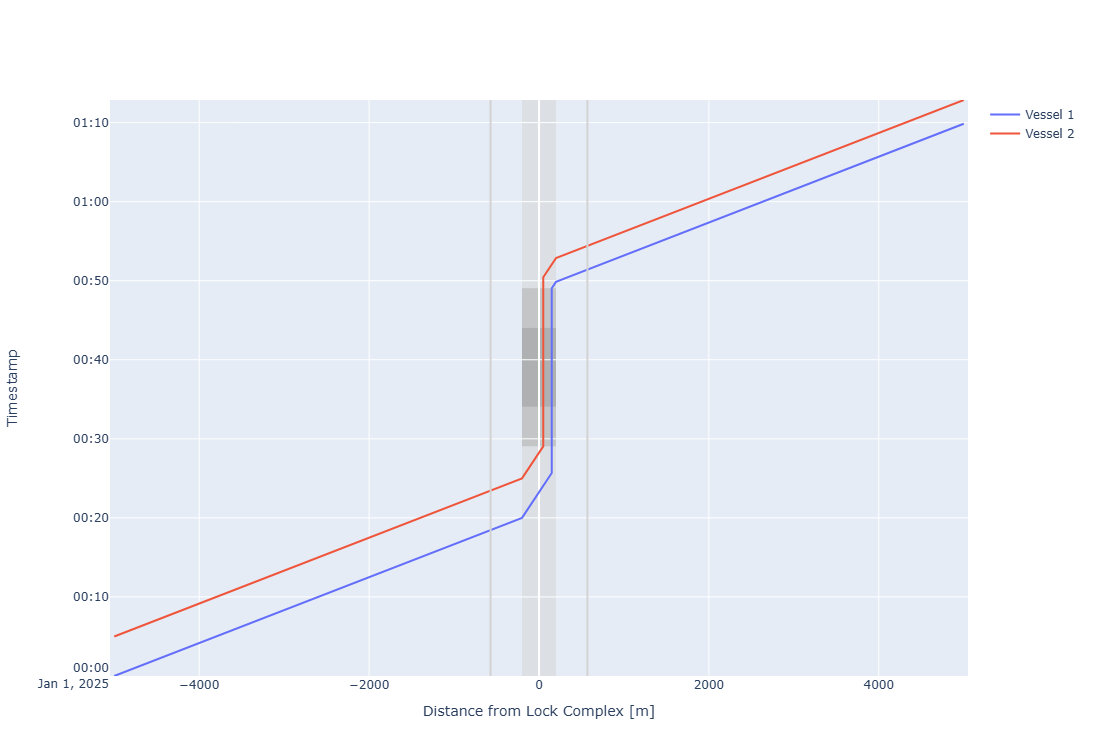

In [15]:
def cm_to_pixels(cm):
    return cm * 37.8 # Set figure height to 10 cmfig.update_layout(height=cm_to_pixels(10))

# We can plot the time-distance diagram
fig = lock_chamber.plot(xlimmin = -5050, 
                        xlimmax = 5050, 
                        method='Plotly')

fig.update_layout(height=cm_to_pixels(20))

##### Event chart
As does the event chart.

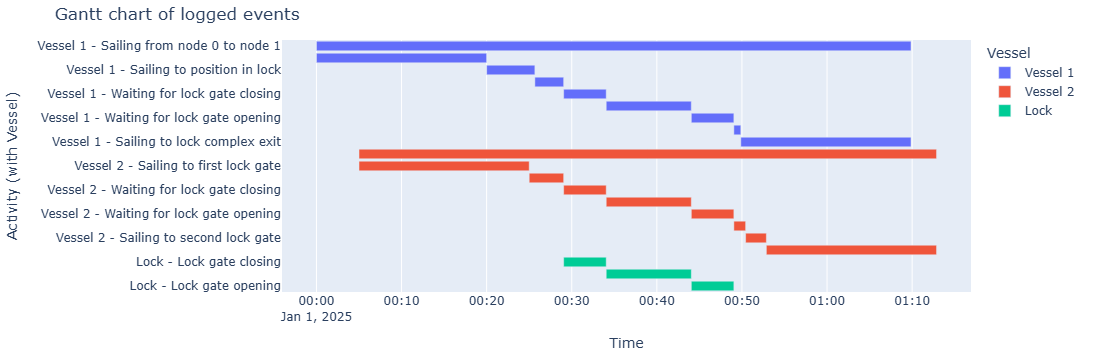

In [16]:
df_eventtable = logbook2eventtable([vessel_1, vessel_2, lock_chamber])
generate_vessel_gantt_chart(df_eventtable)